In [106]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import requests
import warnings
import plotly.express as px
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import time
import json

# prison path from API
# Ask if you want to download new datasets from the API? 
# Set to True if you want to download new datasets, or False if you want to use the existing CSV files in the data folder.
download_new_datasets = (
    input("Do you want to download new datasets from the API? (y/n): ")
    .strip().lower()
    in ["y", "yes"])

if download_new_datasets:
    # AI adoption API links
    prison_data_link = ("https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/crim_pris_age/1.0/*.*.*.*.*?c[freq]=A&"
                        "c[age]=TOTAL,JUVENILE,ADULT&c[sex]=T,M,F&"
                        "c[unit]=NR&"
                        "c[geo]=BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE&"
                        "c[TIME_PERIOD]=2023,2022,2021,2020,2019,2018,2017,2016,2015,2014&compress=false&"
                        "format=csvdata&formatVersion=2.0&"
                        "lang=en&labels=name")

    # Downloading the datasets and saving them as CSV files in the data folder
    prison_data_response = requests.get(prison_data_link)

    with open("../data/prison data/Prison_data.csv", "wb") as f:
        f.write(prison_data_response.content)

# Loading the datasets into pandas DataFrames
prison_data_df = pd.read_csv("../data/prison data/Prison_data.csv")
print(f"Prison Data DataFrame shape: {prison_data_df.shape[0]} rows, {prison_data_df.shape[1]} columns")

Prison Data DataFrame shape: 2315 rows, 21 columns


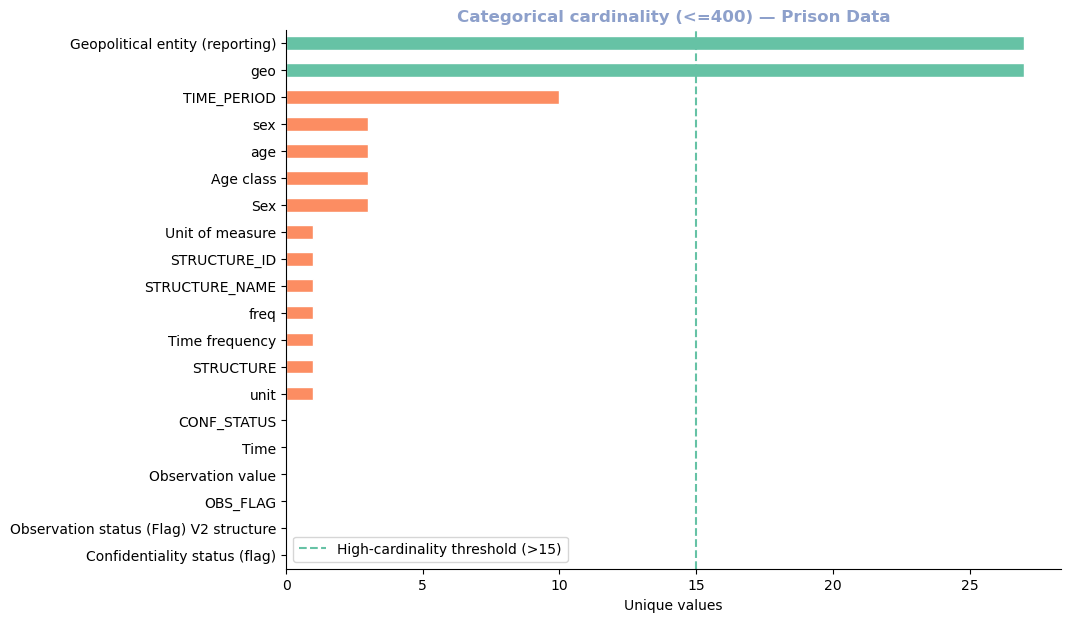

HIGH-CARDINALITY features (excluded from chart):
    'OBS_VALUE': 1492 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data):
  'Confidentiality status (flag)' (0 values): []

  'Observation status (Flag) V2 structure' (0 values): []

  'OBS_FLAG' (0 values): []

  'Observation value' (0 values): []

  'Time' (0 values): []

  'CONF_STATUS' (0 values): []

  'unit' (1 values): ['NR']

  'STRUCTURE' (1 values): ['dataflow']

  'Time frequency' (1 values): ['Annual']

  'freq' (1 values): ['A']

  'STRUCTURE_NAME' (1 values): ['Prisoners by age and sex']

  'STRUCTURE_ID' (1 values): ['ESTAT:CRIM_PRIS_AGE(1.0)']

  'Unit of measure' (1 values): ['Number']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'Age class' (3 values): ['Adult', 'Juvenile', 'Total']

  'age' (3 values): ['ADULT', 'JUVENILE', 'TOTAL']

  'sex' (3 values): ['F', 'M', 'T']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '20

In [ ]:
# cardinality of the dataset
YEARS = range(2008, 2024)
PALETTE = sns.color_palette("Set2")
CORAL, STEEL, NAVY = PALETTE[0], PALETTE[1], PALETTE[2]
def inspect_categorical(df, dataset_name):
    cat_cols = df.select_dtypes(include=["object", "category", "bool", "int64", "float64"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(prison_data_df, "Prison Data")

In [ ]:
country_codes = {
    "Austria": "AUT", "Belgium": "BEL", "Bulgaria": "BGR", 
    "Croatia": "HRV", "Cyprus": "CYP", "Czechia": "CZE", 
    "Estonia": "EST", "Finland": "FIN", "France": "FRA",
    "Germany": "DEU", "Greece": "GRC", "Hungary": "HUN",
    "Ireland": "IRL", "Italy": "ITA","Denmark": "DNK",
    "Latvia": "LVA", "Romania": "ROU",  "Slovakia": "SVK",
    "Lithuania": "LTU", "Luxembourg": "LUX", "Malta": "MLT",
    "Netherlands": "NLD", "Poland": "POL", "Portugal": "PRT",
    "Slovenia": "SVN", "Spain": "ESP", "Sweden": "SWE",
}
area_km2 = {
    "Albania": 28748, "Austria": 83879, "Belgium": 30689,
    "Bulgaria": 110994, "Croatia": 56594, "Poland": 312696,
    "Cyprus": 9251, "Czechia": 78871, "Denmark": 42952,
    "Estonia": 45339, "Finland": 338455, "France": 643801,
    "Germany": 357596, "Greece": 131957, "Hungary": 93030,
     "Ireland": 70273, "Italy": 302068, "Portugal": 92212,
    "Latvia": 64589, "Switzerland": 41285, "Türkiye": 783562,
    "Lithuania": 65300, "Luxembourg": 2586, "Malta": 316,
    "Romania": 238397, "Slovakia": 49035, "Netherlands": 41865, 
    "Slovenia": 20271, "Spain": 505990, "Sweden": 450295,  
}
# Sessione con retry automatici
session = requests.Session()
retry = Retry(
    total=5,
    backoff_factor=2,                              # attese: 2s, 4s, 8s, 16s, 32s
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retry))

# Cache su disco — evita di rifare chiamate già riuscite
CACHE_FILE = Path("worldbank_population_cache.json")
if CACHE_FILE.exists():
    with open(CACHE_FILE) as f:
        _cache = json.load(f)
else:
    _cache = {}
def get_population_world_bank(iso3_code, start_year=2008, end_year=2023):
    cache_key = f"{iso3_code}_{start_year}_{end_year}"
    if cache_key in _cache:
        # converti chiavi anno da str (JSON) a int
        return {int(k): v for k, v in _cache[cache_key].items()}
    url = (
        f"https://api.worldbank.org/v2/country/{iso3_code}/indicator/SP.POP.TOTL"
        f"?format=json&date={start_year}:{end_year}&per_page=100"
    )
    try:
        response = session.get(url, timeout=(15, 90))   # (connect, read)
        response.raise_for_status()
        payload = response.json()
        if not isinstance(payload, list) or len(payload) < 2 or payload[1] is None:
            print(f"[warn] nessun dato per {iso3_code}")
            return {}
        result = {
            int(item["date"]): int(item["value"])
            for item in payload[1]
            if item.get("value") is not None
        }
        # salva in cache
        _cache[cache_key] = result
        with open(CACHE_FILE, "w") as f:
            json.dump(_cache, f)
        return result
    except requests.exceptions.RequestException as e:
        print(f"[warn] errore per {iso3_code}: {e}")
        return {}

country_info = {}
for country, code in country_codes.items():
    country_info[country] = {
        "area_km2": area_km2[country],
        "population_by_year": get_population_world_bank(code, 2008, 2023),
    }
# Manual mapping for regions not in World Bank API
country_info["England and Wales"] = {"area_km2": 151244, "population_by_year": None, "population_fixed": 59641000}
country_info["Scotland (NUTS 2021)"] = {"area_km2": 78803, "population_by_year": None, "population_fixed": 5480000}
country_info["Northern Ireland (UK) (NUTS 2021)"] = {"area_km2": 14333, "population_by_year": None, "population_fixed": 1905000}

# Assign columns after country_info is fully built
prison_data_df["geo"] = prison_data_df["Geopolitical entity (reporting)"].map(country_codes)
prison_data_df["area_km2"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("area_km2")
)
prison_data_df["population_by_year"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_by_year")
)
prison_data_df["population_fixed"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_fixed")
)

In [109]:
def resolve_population(row):
    if row["population_fixed"] is not None and not (isinstance(row["population_fixed"], float) and pd.isna(row["population_fixed"])):
        return row["population_fixed"]
    pop_dict = row["population_by_year"]
    if isinstance(pop_dict, dict):
        return pop_dict.get(row["TIME_PERIOD"])
    return None
prison_data_df["population_year"] = prison_data_df.apply(resolve_population, axis=1)

prison_data_df["Total"] = prison_data_df["OBS_VALUE"].where(prison_data_df["Unit of measure"] == "Number")

# For rows with count, calculate rate
missing_rate = prison_data_df["Total"].isna()
prison_data_df.loc[missing_rate, "Total"] = (prison_data_df.loc[missing_rate, "OBS_VALUE"] * prison_data_df.loc[missing_rate, "population_year"] / 100000).round(2)

prison_data_df.sample(5)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,age,Age class,sex,Sex,unit,...,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag),area_km2,population_by_year,population_fixed,population_year,Total
250,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,ADULT,Adult,F,Females,NR,...,NaN,NaN,NaN,NaN,NaN,49035,"{2023: 5426740, 2022: 5431752, 2021: 5447247, ...",None,5439232,716
740,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,ADULT,Adult,T,Total,NR,...,NaN,NaN,NaN,NaN,NaN,238397,"{2023: 19061062, 2022: 19048502, 2021: 1912205...",None,19061062,23431
929,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,JUVENILE,Juvenile,F,Females,NR,...,NaN,NaN,NaN,NaN,NaN,2586,"{2023: 666430, 2022: 653103, 2021: 640064, 202...",None,582014,0
1727,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,F,Females,NR,...,NaN,NaN,NaN,NaN,NaN,41865,"{2023: 17877117, 2022: 17700982, 2021: 1753304...",None,17344874,724
1052,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,JUVENILE,Juvenile,M,Males,NR,...,NaN,NaN,NaN,NaN,NaN,9251,"{2023: 1344976, 2022: 1331370, 2021: 1317309, ...",None,1201801,23


In [110]:
# Drop columns 
prison_data_df.drop(columns=[
    'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'age', 'sex',
    'Confidentiality status (flag)', 'OBS_FLAG', 'Observation value', 'Time', 'CONF_STATUS',
    'STRUCTURE', 'Observation status (Flag) V2 structure', 'Unit of measure', 'OBS_VALUE',
    'population_by_year', 'population_fixed'], inplace=True)

prison_data_df.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Total
444,Adult,Males,MLT,Malta,2023,316,552747,623
1172,Juvenile,Males,LTU,Lithuania,2015,65300,2911109,84
472,Adult,Males,PRT,Portugal,2021,92212,10361831,10634
751,Adult,Total,SVN,Slovenia,2014,20271,2061980,1517
1013,Juvenile,Females,SVN,Slovenia,2023,20271,2120461,1


In [111]:
gender_path = Path('../data/Data to export//cleaned_gender_index.csv')
gender_data = pd.read_csv(gender_path)

gender_data = gender_data.melt(
    id_vars='Country', var_name='TIME_PERIOD', value_name='Gender_index'
)
gender_data['TIME_PERIOD'] = gender_data['TIME_PERIOD'].astype(int)
# add a column to prison_data with the gender index for each country and year
prison_data = prison_data_df.merge(
    gender_data,
    left_on=['Geopolitical entity (reporting)', 'TIME_PERIOD'],
    right_on=['Country', 'TIME_PERIOD'],
    how='left'
).drop(columns='Country')
prison_data.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Total,Gender_index
1896,Total,Males,FRA,France,2020,643801,67601110,60488,0.781
961,Juvenile,Females,NLD,Netherlands,2018,41865,17231624,19,0.747
1387,Juvenile,Total,HRV,Croatia,2015,56594,4151725,51,0.708
1800,Total,Males,AUT,Austria,2023,83879,9131761,8475,0.740
1002,Juvenile,Females,SWE,Sweden,2021,450295,10415811,2,0.823


In [112]:
# We separate the row where the 'Age class' and 'Sex' columns have the value 'Total'
total_values = prison_data[(prison_data['Age class'] == 'Total') | (prison_data['Sex'] == 'Total')]
# then drop them from the original dataset
prison_data.drop(total_values.index, inplace=True)
total_values.head(10)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Total,Gender_index
514,Adult,Total,AUT,Austria,2014,83879,8546356,8612,0.7266
515,Adult,Total,AUT,Austria,2015,83879,8642699,8555,0.7330
516,Adult,Total,AUT,Austria,2016,83879,8736668,8503,0.7160
517,Adult,Total,AUT,Austria,2017,83879,8797566,8710,0.7090
518,Adult,Total,AUT,Austria,2018,83879,8840521,9034,0.7180
519,Adult,Total,AUT,Austria,2019,83879,8879920,8925,0.7310
520,Adult,Total,AUT,Austria,2020,83879,8916864,8397,0.7440
521,Adult,Total,AUT,Austria,2021,83879,8955797,8340,0.7770
522,Adult,Total,AUT,Austria,2022,83879,9041851,8904,0.7810
523,Adult,Total,AUT,Austria,2023,83879,9131761,8970,0.7400


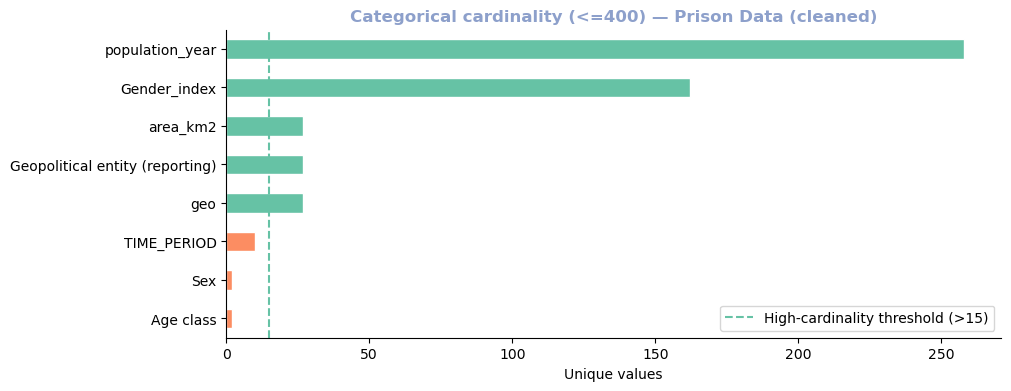

HIGH-CARDINALITY features (excluded from chart):
    'Total': 611 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (cleaned)):
  'Age class' (2 values): ['Adult', 'Juvenile']

  'Sex' (2 values): ['Females', 'Males']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (27 values): ['AUT', 'BEL', 'BGR', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']

  'Geopolitical entity (reporting)' (27 values): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']

  'area_km2' (27 values): ['110994', '131957', '20271', '238397', '2586'

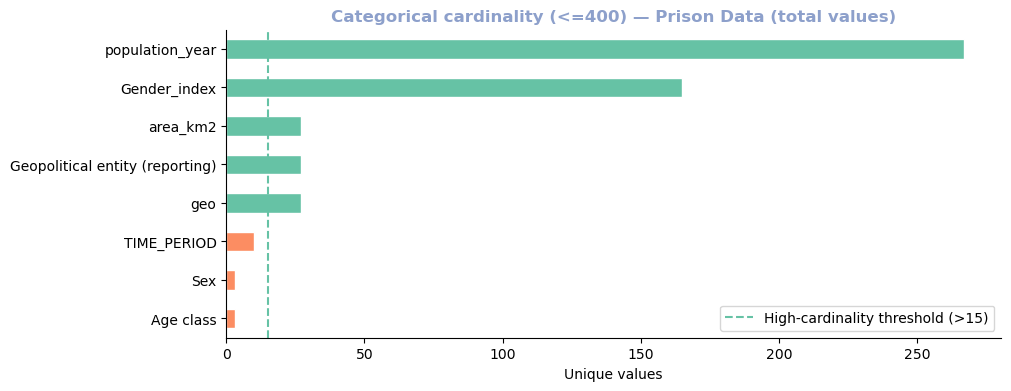

HIGH-CARDINALITY features (excluded from chart):
    'Total': 1085 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (total values)):
  'Age class' (3 values): ['Adult', 'Juvenile', 'Total']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (27 values): ['AUT', 'BEL', 'BGR', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']

  'Geopolitical entity (reporting)' (27 values): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']

  'area_km2' (27 values): ['110994', '131957', '

In [113]:
inspect_categorical(prison_data, "Prison Data (cleaned)")
inspect_categorical(total_values, "Prison Data (total values)")

In [114]:
# Save the cleaned dataset in Data to export folder
prison_data.to_csv('../data/Data to export//cleaned_prison_data.csv', index=False)
total_values.to_csv('../data/Data to export//total_values_prison_data.csv', index=False)

In [117]:
# Parameters
TIME_PERIOD = 2015          # Anno disponibile: 2014-2023
SEX         = 'Females'     # Opzioni: 'Females', 'Males', 'Total'
AGE_CLASS   = 'Total'       # Opzioni: 'Adult', 'Juvenile', 'Total' 

# Validazione parametri
assert TIME_PERIOD in total_values['TIME_PERIOD'].unique(), \
    f"Anno non valido. Disponibili: {sorted(total_values['TIME_PERIOD'].unique())}"
assert SEX in total_values['Sex'].unique(), \
    f"Sesso non valido. Opzioni: {total_values['Sex'].unique().tolist()}"
assert AGE_CLASS in total_values['Age class'].unique(), \
    f"Age class non valida. Opzioni: {total_values['Age class'].unique().tolist()}"

filtered = total_values[
    (total_values['TIME_PERIOD'] == TIME_PERIOD) &
    (total_values['Sex']         == SEX)         &
    (total_values['Age class']   == AGE_CLASS)
]
# Aggrega per paese
agg = (
    filtered.groupby('Geopolitical entity (reporting)')['Total']
    .mean()
    .reset_index()
)
agg.columns = ['country', 'value']
agg['value'] = agg['value'].round(1)
agg['iso3']  = agg['country'].map(country_codes)
agg = agg[agg['iso3'].notna()].copy()

print(f"Paesi con dati disponibili: {len(agg)}")
print(agg.sort_values('value', ascending=False).to_string(index=False))

# Mappa statica
fig = px.choropleth(
    agg,
    locations='iso3',
    color='value',
    hover_name='country',
    hover_data={'value': ':.1f', 'iso3': False},
    color_continuous_scale='YlOrRd',
    labels={'value': 'Per 100k abitanti'},
    title=f'Detenuti per 100.000 abitanti — Europa'
          f'<br><sup>Anno: {TIME_PERIOD} | Genere: {SEX} | Classe: {AGE_CLASS}</sup>',
    scope='europe',
)
fig.update_geos(
    visible=True, resolution=50,
    showcoastlines=True, coastlinecolor='#444',
    showland=True,  landcolor='#2d2d3e',
    showocean=True, oceancolor='#1a1a2e',
    showlakes=True, lakecolor='#1a1a2e',
    showframe=False,
    projection_type='natural earth',
    lataxis_range=[34, 72], lonaxis_range=[-25, 45],
    bgcolor='#1a1a2e',
)
fig.update_layout(
    title_font=dict(size=18, color='white'),
    paper_bgcolor='#1a1a2e',
    font=dict(color='white'),
    coloraxis_colorbar=dict(
        title=dict(text='Per 100k abitanti', font=dict(color='white', size=12)),
        tickfont=dict(color='white'),
        bgcolor='rgba(30,30,50,0.8)',
        bordercolor='#555', borderwidth=1,
        len=0.7, thickness=15,
    ),
    margin=dict(l=0, r=0, t=80, b=0),
    height=650,
)
# Disabilita interattività — mappa statica
fig.show(config={
    'staticPlot': False,       # nessun zoom/pan/hover
    'displayModeBar': False,  # nasconde la toolbar
})

Paesi con dati disponibili: 27
    country  value iso3
      Spain 4658.0  ESP
    Germany 3609.0  DEU
     Poland 2579.0  POL
      Italy 2207.0  ITA
     France 2147.0  FRA
    Romania 1443.0  ROU
    Czechia 1433.0  CZE
    Hungary 1250.0  HUN
   Portugal  855.0  PRT
   Slovakia  631.0  SVK
    Belgium  529.0  BEL
Netherlands  499.0  NLD
    Austria  498.0  AUT
     Greece  486.0  GRC
     Latvia  358.0  LVA
     Sweden  327.0  SWE
  Lithuania  296.0  LTU
   Bulgaria  246.0  BGR
    Finland  237.0  FIN
    Croatia  164.0  HRV
    Estonia  155.0  EST
    Denmark  118.0  DNK
    Ireland  116.0  IRL
   Slovenia   81.0  SVN
      Malta   41.0  MLT
 Luxembourg   40.0  LUX
     Cyprus   32.0  CYP
